# Project 5: **Build a Multi-Modal Generation Agent**

Welcome to the final project! In this project, you'll use open-source text-to-image and text-to-video models to generate content. Next, you'll build a **unified multi-modal agent** similar to modern chatbots, where a single agent can support general questions, image generation, and video generation requests.

By the end of this project, you'll understand how to integrate multiple model types under one  routing system capable of deciding what modality to use based on the user's intent.



## Learning Objectives

* Use **Text-to-Image** models to generate images from a text.
* Generate short clips with a **Text-to-Video** model
* Build a **Multi-Modal Agent** that answers questions and routes media requests
* Build a simple **Gradio** UI and interact with the multi-modal agent

## Roadmap
1. Environment setup
2. Text‑to‑Image
3. Text‑to‑Video
4. Multimodal Agent
5. Gradio UI
6. Celebrate

## 1 - Environment Setup

In this project, we'll use open-source Text-to-Image and Text-to-Video models to generate visuals from natural-language prompts. These models are computationally heavy and perform best on GPUs, so we recommend running this notebook in Google Colab or another GPU-enabled environment. We'll load all models from Hugging Face, which requires authentication.

Before continuing:
1. Open this project in Google Colab.
2. Create a Hugging Face account and generate an access token at `huggingface.co/settings/tokens`
3. Paste your token in the field below.
4. In the Colab environment, enable GPU acceleration by selecting Runtime → Change runtime type → a GPU-enabled machine (e.g., T4 GPU).

In [ ]:
from huggingface_hub import login
import os

HF_ACCESS_TOKEN = "YOUR_TOKEN_HERE"

login(token=HF_ACCESS_TOKEN)
os.environ["HF_TOKEN"] = HF_ACCESS_TOKEN

Let's import the required libraries and confirm that PyTorch can detect the available GPU.

In [2]:
import torch, diffusers, transformers, os, random, gc
print('torch', torch.__version__, '| CUDA:', torch.cuda.is_available())

torch 2.9.0+cu128 | CUDA: True


## 2 - Text-to-Image (T2I)
T2I models translate natural-language descriptions into images. They are typically based on diffusion models, which gradually refine random noise into a coherent picture guided by the text prompt. In this section, you'll load and test T2I models to generate images directly from text inputs.

### 2.1: Load a T2I Model
We'll use **Stable Diffusion v1.5**, a well-established **UNet-based** diffusion model that runs comfortably on Google Colab's free GPU tier. It produces solid 512x512 images and is a great starting point for learning the diffusion pipeline.

If you have access to a more powerful machine or a paid Colab tier with extra RAM, you can explore these newer, larger alternatives:

- **SSD-1B** by Segmind (`segmind/SSD-1B`): a distilled version of Stable Diffusion XL (SDXL). Also **UNet-based**, but produces higher-resolution images at ~2.5 GB in fp16. Requires more GPU memory than the free Colab tier typically provides.
- **PixArt-Sigma** by PixArt-alpha (`PixArt-alpha/PixArt-Sigma-XL-2-512-MS`): a newer model based on a **Diffusion Transformer (DiT)** architecture with 0.6B parameters. DiT replaces the UNet backbone with a transformer, which can improve scalability and image quality — but also demands more memory.

Use `enable_attention_slicing()` to keep GPU memory usage low and prevent out-of-memory (OOM) crashes when multiple models coexist.

You'll load the model from Hugging Face using the diffusers library. To learn more: https://huggingface.co/docs/diffusers/main/index

In [ ]:
from diffusers import DiffusionPipeline

# Load `stable-diffusion-v1-5` model using DiffusionPipeline.
"""
YOUR CODE HERE (~2 lines of code)
"""

model_id = 'stable-diffusion-v1-5/stable-diffusion-v1-5'
pipe_img = DiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16, variant='fp16', use_safetensors=True).to("cuda")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--stable-diffusion-v1-5--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--stable-diffusion-v1-5--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [4]:
pipe_img.enable_attention_slicing()

### 2.2: Generate an image

  0%|          | 0/50 [00:00<?, ?it/s]

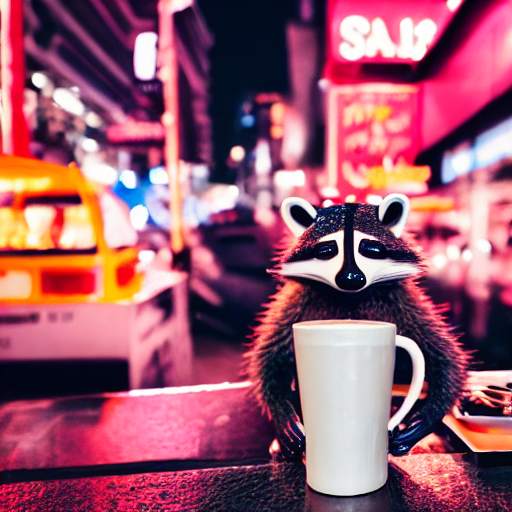

In [4]:
# Generate and display an image from a text prompt using the loaded pipeline
"""
YOUR CODE HERE (~2 lines of code)
"""

prompt = 'A raccoon barista serves a latte on a rainy neon street, shot on 50mm.'
image = pipe_img(prompt).images[0]
image

### 2.3: Experimenting with "inference_steps"

The number of inference steps determines how many refinement passes the diffusion model makes. Fewer steps give quicker but less detailed images, while more steps improve clarity and structure at the cost of speed.

Try generating images with different step counts and compare the results.

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

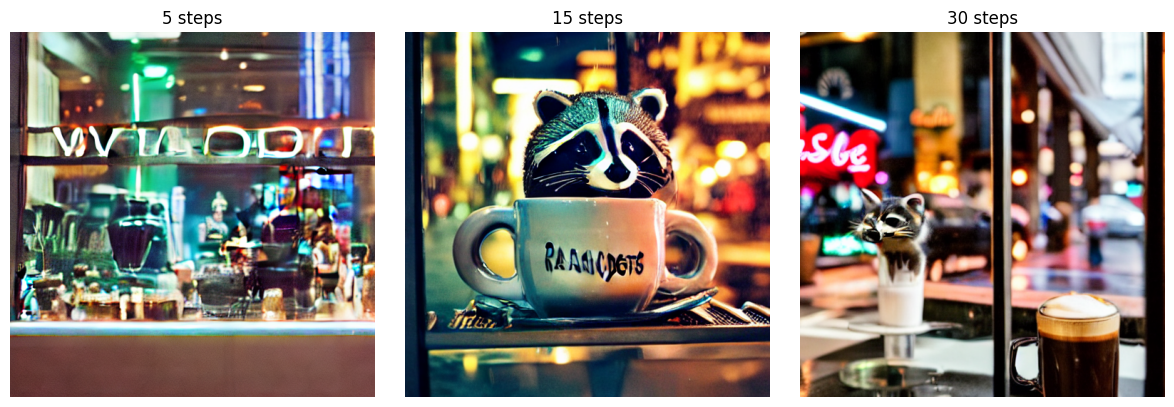

In [ ]:
# Generate an image for different values of num_inference_steps (e.g., 10, 25, 50) and compare sharpness and detail

import matplotlib.pyplot as plt

images = []

"""
YOUR CODE HERE (~5 lines)
"""

prompt = "A raccoon barista serves a latte on a rainy neon street, shot on 50mm."
steps_list = [5, 15, 30]  # try changing these values

for steps in steps_list:
    image = pipe_img(prompt=prompt, num_inference_steps=steps, guidance_scale=7.5).images[0]
    images.append((steps, image))

# Plot results side-by-side
plt.figure(figsize=(12, 4))
for i, (steps, img) in enumerate(images, 1):
    plt.subplot(1, len(images), i)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{steps} steps")
plt.tight_layout()
plt.show()


### 2.4 (Optional): Visualizing the Diffusion Process
Diffusion models start from random noise and iteratively refine it into an image that matches the prompt. If you are curious, visualize all intermediate steps to see how the noise gradually turns into a coherent picture.

  0%|          | 0/30 [00:00<?, ?it/s]

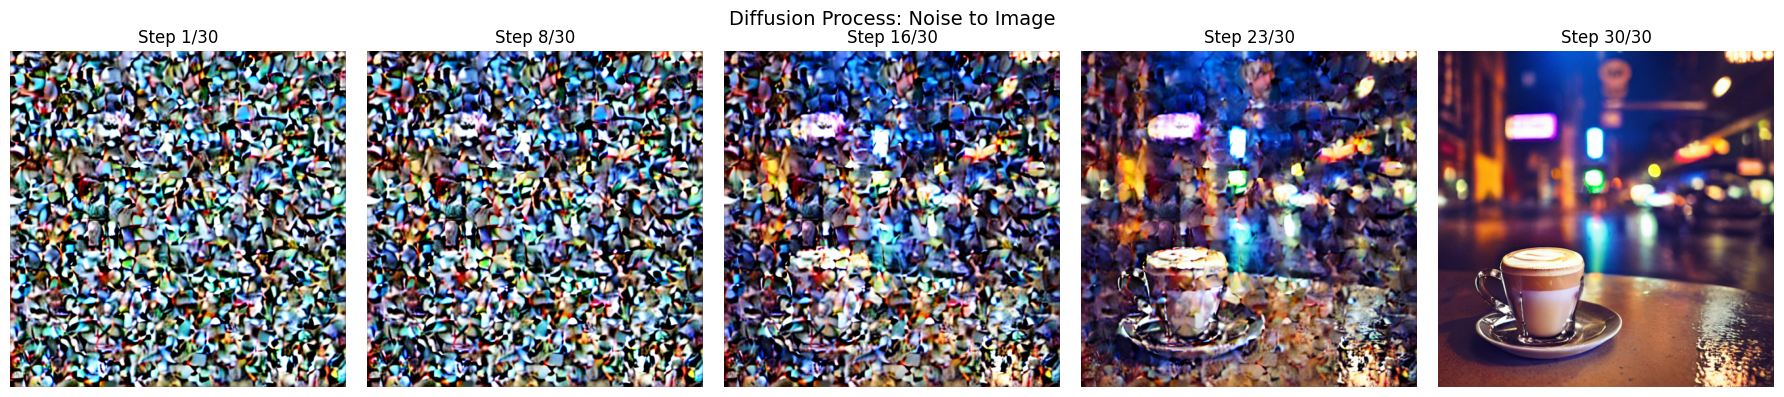

In [ ]:
import torch
import matplotlib.pyplot as plt

# Step 1: Run the pipeline with 30 inference steps
# Step 2: Capture intermediate latents during generation using a callback
# Step 3: Decode selected latents through the VAE and plot them

prompt = "A raccoon barista serves a latte on a rainy neon street, shot on 50mm."
num_steps = 30
latents_over_time = []

def capture_latents(pipe, step, timestep, callback_kwargs):
    """Callback that saves a copy of the latent tensor at each denoising step."""
    latents_over_time.append(callback_kwargs["latents"].detach().clone())
    return callback_kwargs

# Run the pipeline, capturing latents at every step
image = pipe_img(
    prompt,
    num_inference_steps=num_steps,
    callback_on_step_end=capture_latents,
).images[0]

# Pick evenly spaced steps to visualize the progression
indices = [0, num_steps // 4, num_steps // 2, 3 * num_steps // 4, num_steps - 1]
fig, axes = plt.subplots(1, len(indices), figsize=(18, 4))

for ax, idx in zip(axes, indices):
    with torch.no_grad():
        latent = latents_over_time[idx].to(dtype=torch.float16)
        decoded = pipe_img.vae.decode(
            latent / pipe_img.vae.config.scaling_factor, return_dict=False
        )[0]
    img_np = (decoded[0] / 2 + 0.5).clamp(0, 1).permute(1, 2, 0).cpu().float().numpy()
    ax.imshow(img_np)
    ax.set_title(f"Step {idx + 1}/{num_steps}")
    ax.axis("off")

plt.suptitle("Diffusion Process: Noise to Image", fontsize=14)
plt.tight_layout()
plt.show()

### 2.5 (Optional): Experiment with other models.
Different text-to-image models vary in speed, style, and visual quality. If you have access to more powerful machines, try swapping in other open-source diffusion models and compare how their outputs differ in detail, realism, or artistic tone.

You can browse available models on Hugging Face here: https://huggingface.co/models?library=diffusers

In [ ]:
# Step 1: Replace model_id with another text-to-image model from Hugging Face
# Step 2: Reload the pipeline and generate a few test images
# Step 3: Compare image quality, color balance, and prompt fidelity
"""
YOUR CODE HERE
"""

## 3 - Text-to-Video (T2V)
T2V models extend the idea of diffusion from still images to moving sequences. Instead of generating one frame, they create a series of coherent frames that depict motion consistent with the text prompt. These models are computationally heavier and often generate short clips (typically 2-10 seconds).

In this section, you'll load an open-source video diffusion model and generate videos.

### 3.1: Load a T2V model
We'll use **damo-vilab 1.7B** (`damo-vilab/text-to-video-ms-1.7b`), a **UNet-based** video diffusion model that generates 256x256 clips. It is lightweight enough to run on Google Colab's free GPU tier, making it a practical choice for learning text-to-video generation.

If you have access to more powerful hardware or a paid Colab tier, you can explore this newer alternative:

- **Wan 2.1 T2V 1.3B** by Alibaba (`Wan-AI/Wan2.1-T2V-1.3B-Diffusers`): a modern **DiT-based** video model that generates **480p** video with significantly better motion coherence. It uses a specialized 3D causal VAE to reduce flickering. While the parameter count is comparable, the DiT architecture and higher output resolution require substantially more GPU memory than the free Colab tier provides.

In [ ]:
# Free cached GPU tensors before loading the video model.
gc.collect()
torch.cuda.empty_cache()
print("GPU cache cleared.")

GPU cache cleared.


Load the `damo-vilab/text-to-video-ms-1.7b` model, which produces short video clips from text prompts and fits within free Colab's memory limits.

In [ ]:
from diffusers import DiffusionPipeline

# Load `text-to-video-ms-1.7b` model using DiffusionPipeline.
"""
YOUR CODE HERE (~2 lines of code)
"""

video_model_id = 'damo-vilab/text-to-video-ms-1.7b'
pipe_vid = DiffusionPipeline.from_pretrained(video_model_id, torch_dtype=torch.float16, variant="fp16").to("cuda")

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--damo-vilab--text-to-video-ms-1.7b/snapshots/8227dddca75a8561bf858d604cc5dae52b954d01/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The TextToVideoSDPipeline has been deprecated and will not receive bug fixes or feature updates after Diffusers version 0.33.1. 


### 3.2: Generate a clip
Create a short video clip from a text prompt using a text-to-video model.

In [5]:
# Step 1: Write a text prompt describing the video you want to generate
# Step 2: Run the text-to-video pipeline with your chosen prompt
"""
YOUR CODE HERE (~2-3 lines)
"""

prompt = "A raccoon barista slides a latte across a counter as rain streaks the café window and neon lights flicker outside."

# (damo-vilab): 16 frames at 256x256
vid_frames = pipe_vid(prompt, num_frames=16, num_inference_steps=25).frames[0]

print(f"Generated {len(vid_frames)} frames")

  0%|          | 0/25 [00:00<?, ?it/s]

Generated 16 frames


### 3.3: Frame inspection
Inspect a single frame to sanity-check colors, resolution, and subject positioning before writing a full video.

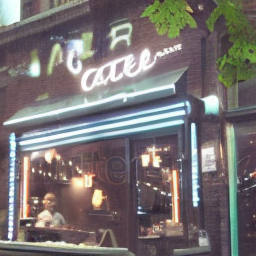

In [ ]:
import numpy as np
from PIL import Image

# Step 1: Select one frame from vid_frames (e.g., index 0)
# Step 2: Display as a PIL image (use Image.fromarray)
"""
YOUR CODE HERE (~1-2 lines)
"""
Image.fromarray((vid_frames[0]*255).astype(np.uint8))


### 3.4: Convert frames to MP4
Write the generated frames to an MP4 file so you can preview and share the result.

In [7]:
# Step 1: Use diffusers.utils.export_to_video to write vid_frames to an MP4
# Step 2: Capture and print the saved video path
"""
YOUR CODE HERE (~3-4 lines)
"""

from diffusers.utils import export_to_video
video_path = export_to_video(vid_frames)
video_path

'/tmp/tmp_pqn_tv3.mp4'

### 3.5: Video inspection
Play the saved video inside the notebook to check motion and temporal consistency.

In [8]:
# Display the saved MP4 inline
from IPython.display import Video

"""
YOUR CODE HERE (1 line of code)
"""

Video(video_path, embed=True)

### 3.6 (Optional): Experiment with different configs
Increase `num_frames` or decrease `num_inference_steps` to experiment with clip length versus quality.

## 4 - Multimodal Generation Agent
Now that you have working text-to-image and text-to-video pipelines, you will build a single agent that routes user requests to the right capability. The agent will read a prompt, infer intent (chat vs. image vs. video), and return the appropriate output.

To do this, we also need a small LLM. It will serve a dual role: answering general questions directly, and acting as a **router** that classifies each user prompt so the agent knows which pipeline to call.

### 4.1: Load an LLM for generic queries
Load `gemma-3-1b-it` using the Hugging Face `pipeline`. This compact model is small enough to coexist in memory alongside the image and video pipelines on the free Colab tier.

In [ ]:
from transformers import pipeline

# Load google/gemma-3-1b-it using HuggingFace pipeline

"""
YOUR CODE HERE (~2-15 lines)
"""

model_id = "google/gemma-3-1b-it"
gemma_llm = pipeline("text-generation", model=model_id, dtype=torch.float16, device_map="auto")

Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

### 4.2: Build a routing mechanism to route requests

**Step 1:** Implement two helper functions:
- `generate_media(prompt, mode)` — a thin wrapper that calls the image pipeline when `mode='image'` or the video pipeline when `mode='video'`.
- `llm_generate(prompt, ...)` — sends a prompt to the Gemma LLM and returns the generated text.

In [ ]:
import torch, textwrap, json, re

def generate_media(prompt: str, mode: str):
    # Produce either an image or a short video clip from a text prompt.
    """
    YOUR CODE HERE (~3-6 lines)
    """
    if mode == 'image':
        return pipe_img(prompt).images[0]
    else:
        return pipe_vid(prompt, num_frames=16, num_inference_steps=25).frames[0]

def llm_generate(prompt, max_new_tokens=64, temperature=0.7):
    # Return a response to the prompt with the loaded gemma
    """
    YOUR CODE HERE (~2 lines of code)
    """
    outputs = gemma_llm(prompt, max_new_tokens=max_new_tokens, do_sample=True, temperature=temperature)
    return outputs[0][0]["generated_text"][-1]["content"]

**Step 2:** Implement `classify_prompt(prompt)` — the router. This function uses the LLM itself to classify a user prompt into one of three categories: `"qa"`, `"image"`, or `"video"`. For image and video requests, it should also return an `expanded_prompt` — an improved, more detailed version of the user's request that will produce better generation results. On parse failure, default to `"qa"`.

In [8]:
def classify_prompt(prompt: str):
    """Classify the user prompt into QA, image, or video."""

    # Step 1: Define a system prompt explaining how to classify requests (qa, image, video)
    # Step 2: Format the user message and system message as input to the LLM
    # Step 3: Generate a response with llm_generate() and parse it using regex
    # Step 4: Extract fields "type" and "expanded_prompt" from the LLM response
    # Step 5: Return a dict with classification results or default to {"type": "qa"} on failure

    """
    YOUR CODE HERE (~5-25 lines of code)
    """

    system = textwrap.dedent("""You are a routing assistant for a multimodal generation system.
        Decide whether the USER request is:
          • a factual or conversational question  →  type = "qa"
          • an IMAGE generation request          →  type = "image"
          • a VIDEO generation request           →  type = "video"
        If it is for image or video, produce an improved, vivid, detailed `expanded_prompt`.
        Respond ONLY in this format: {"type": "...", "expanded_prompt": "..."}
    """)

    messages = [
      [
          {
              "role": "system",
              "content": [{"type": "text", "text": system},]
          },
          {
              "role": "user",
              "content": [{"type": "text", "text": prompt},]
          },
      ],
    ]
    response = llm_generate(messages, temperature=0.2)
    match = re.search(r'"type"\s*:\s*"([^"]+)"\s*,\s*"expanded_prompt"\s*:\s*"([^"]+)', response)
    if match:
        try:
            result = {
              "type": match.group(1),
              "expanded_prompt": match.group(2)
            }
            return result
        except Exception:
            pass
    # fallback
    return {"type": "qa"}

### 4.3: Build the multimodal agent
Implement `multimodal_agent(user_prompt)` — the main entry point. It takes a single user prompt, calls `classify_prompt` to determine the request type, and then routes to the appropriate handler:
- **QA** — call `llm_generate` to produce a conversational answer.
- **Image** — call `generate_media` with the expanded prompt and `mode='image'`.
- **Video** — call `generate_media` with the expanded prompt and `mode='video'`.

In [9]:
def multimodal_agent(user_prompt: str):
    # Step 1: Classify the request
    # Step 2: Route the prompt and generate output

    """
    YOUR CODE HERE (~12-16 lines)
    """

    decision = classify_prompt(user_prompt)
    kind = decision.get('type', 'qa')
    if kind == 'qa':
        system = "You are a helpful assistant."
        messages = [
            [
                {
                    "role": "system",
                    "content": [{"type": "text", "text": system},]
                },
                {
                    "role": "user",
                    "content": [{"type": "text", "text": user_prompt},]
                },
            ],
        ]
        return llm_generate(messages)
    else:
        return generate_media(decision['expanded_prompt'], mode=kind)

### 4.4: Test the agent
Now let's test your multimodal agent end to end. Each prompt will automatically be routed to the correct capability: text Q&A, image generation, or video generation, and display the corresponding output.

Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'do_sample', 'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_clas


PROMPT: What's the capital of Iceland?
The capital of Iceland is **Reykjavik**.


  0%|          | 0/50 [00:00<?, ?it/s]


PROMPT: Generate an image of a neon dragon flying over Tokyo at night


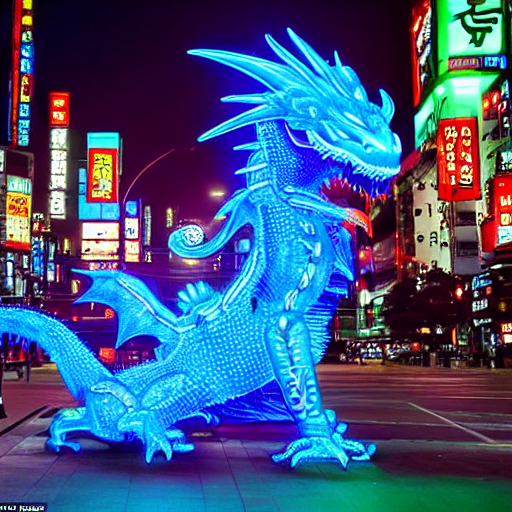

Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  0%|          | 0/25 [00:00<?, ?it/s]


PROMPT: Create a short video of a paper plane folding itself
video path: /tmp/tmpam4czze_.mp4


In [10]:
from diffusers.utils import export_to_video
from IPython.display import display, Video

# Step 1: Define a few diverse prompts (QA, image, video)
# Step 2: For each prompt, call multimodal_agent and inspect the returned result
"""
YOUR CODE HERE (~15-18 lines)
"""

for p in [
    "What's the capital of Iceland?",
    "Generate an image of a neon dragon flying over Tokyo at night",
    "Create a short video of a paper plane folding itself"
]:
    result = multimodal_agent(p)
    print('\nPROMPT:', p)
    if isinstance(result, str):
        print(result)
    else:
        if hasattr(result, 'save'):
            display(result)
        else:
            vid = export_to_video(result)
            print(f"video path: {vid}")
            display(Video(vid, embed=True))

Replace the sample queries with your own and verify that the agent chooses the correct generation path.

## 5 (Optional) - Interactive Web UI

Launch a simple Gradio web interface so you (or your users) can play with the multimodal agent from the browser.


In [14]:
import gradio as gr
with gr.Blocks() as demo:
    gr.Markdown('# Multimodal Agent')
    inp = gr.Textbox(placeholder='Ask or create...')
    btn = gr.Button('Submit')
    out_text = gr.Markdown()
    out_img = gr.Image()
    out_vid = gr.Video()

    def handle(prompt):
        res = multimodal_agent(prompt)
        if isinstance(res, str):
            return res, None, None
        elif hasattr(res, 'save'):
            return '', res, None
        else:
            vid = export_to_video(res)
            return '', None, vid

    btn.click(handle, inp, [out_text, out_img, out_vid])

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://90902e2068f8aec8c9.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


After the UI launches, open the link and generate your own images and videos directly from the browser.

## 🎉 Congratulations!

* You have built a **multi-modal agent** capable of understanding various requests, and routing them to the proper model.
* Try experimenting with other T2I and T2V models.
* Try making your system more efficient. For example, load a separate lightweight llm for routing, and a more capable llm for QA.


👏 **Great job!** Take a moment to celebrate. The techniques you implemented here power many production agents and chatbots.